In [22]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics -q
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/ppe-project/models/best.pt')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os

test_img_dir = '/content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images'
test_images = os.listdir(test_img_dir)
print(test_images[:5])  # see actual filenames

['-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg', '000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg', '002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg', '003357_jpg.rf.9867f91e88089bb68dc95947d5116d14.jpg', '004063_jpg.rf.1b7cdc4035bcb24ef69b8798b444053e.jpg']


In [24]:
sample_image_path = os.path.join(test_img_dir, test_images[0])
print(sample_image_path)

results = model(sample_image_path)

for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f"Class: {model.names[cls_id]}, Confidence: {conf:.2f}, Box: {xyxy}")

/content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg

image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg: 640x640 1 Hardhat, 1 Mask, 1 Person, 231.5ms
Speed: 3.1ms preprocess, 231.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Class: Mask, Confidence: 0.56, Box: [100.81314086914062, 0.0, 392.0290222167969, 308.6780090332031]
Class: Person, Confidence: 0.38, Box: [299.4666442871094, 365.732666015625, 406.7734680175781, 458.1346435546875]
Class: Hardhat, Confidence: 0.25, Box: [324.5787353515625, 367.4517822265625, 347.982666015625, 392.67950439453125]


In [25]:
sample_image_path = os.path.join(test_img_dir, test_images[1])
print(sample_image_path)

results = model(sample_image_path)

for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f"Class: {model.names[cls_id]}, Confidence: {conf:.2f}, Box: {xyxy}")

/content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg

image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg: 640x640 2 Hardhats, 3 NO-Masks, 1 NO-Safety Vest, 3 Persons, 1 machinery, 274.6ms
Speed: 2.8ms preprocess, 274.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Class: Hardhat, Confidence: 0.90, Box: [405.6768798828125, 204.97613525390625, 500.1641845703125, 364.06317138671875]
Class: Hardhat, Confidence: 0.89, Box: [43.35791015625, 132.35507202148438, 176.26889038085938, 269.56365966796875]
Class: NO-Mask, Confidence: 0.79, Box: [60.5469970703125, 279.80657958984375, 133.12496948242188, 341.57086181640625]
Class: Person, Confidence: 0.75, Box: [0.12359619140625, 126.52752685546875, 176.89816284179688, 637.7363891601562]
Class: NO-Mask, Confidence: 0.52, Box: [452.83074951171875, 274.98040771484375, 495.4515

In [26]:
sample_image_path = os.path.join(test_img_dir, test_images[2])
print(sample_image_path)

results = model(sample_image_path)

for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f"Class: {model.names[cls_id]}, Confidence: {conf:.2f}, Box: {xyxy}")

/content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg

image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg: 640x640 2 Hardhats, 3 NO-Masks, 2 NO-Safety Vests, 2 Persons, 1 machinery, 354.0ms
Speed: 6.3ms preprocess, 354.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Class: Hardhat, Confidence: 0.86, Box: [329.73358154296875, 22.56280517578125, 391.37713623046875, 132.91470336914062]
Class: Person, Confidence: 0.83, Box: [91.88833618164062, 111.34786987304688, 139.1963348388672, 245.25839233398438]
Class: Hardhat, Confidence: 0.74, Box: [108.81937408447266, 113.31475830078125, 126.2727279663086, 129.0571746826172]
Class: NO-Safety Vest, Confidence: 0.73, Box: [185.9036865234375, 50.95281982421875, 333.85382080078125, 278.7026672363281]
Class: Person, Confidence: 0.73, Box: [162.54844665527344, 102.63575744628906

In [27]:
VIOLATION_CLASSES = ['NO-Hardhat', 'NO-Mask', 'NO-Safety Vest']
CONFIDENCE_THRESHOLD = 0.4  # tune this based on your model's precision/recall tradeoff

def detect_violations(image_path, model, confidence_threshold=CONFIDENCE_THRESHOLD):
    """
    Runs detection on an image and returns structured violation data.
    """
    results = model(image_path, conf=confidence_threshold)
    violations = []

    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id]
        conf = float(box.conf[0])
        xyxy = box.xyxy[0].tolist()

        if cls_name in VIOLATION_CLASSES:
            violations.append({
                'image': image_path,
                'violation_type': cls_name,
                'confidence': round(conf, 3),
                'bbox': xyxy
            })

    return violations

In [28]:
import os

test_img_dir = '/content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images'
sample_images = os.listdir(test_img_dir)[:10]

all_violations = []
for img_file in sample_images:
    img_path = os.path.join(test_img_dir, img_file)
    violations = detect_violations(img_path, model)
    all_violations.extend(violations)

for v in all_violations:
    print(v)


image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg: 640x640 1 Mask, 332.6ms
Speed: 4.0ms preprocess, 332.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg: 640x640 2 Hardhats, 2 NO-Masks, 2 Persons, 240.3ms
Speed: 2.7ms preprocess, 240.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg: 640x640 2 Hardhats, 2 NO-Masks, 2 NO-Safety Vests, 2 Persons, 1 machinery, 234.1ms
Speed: 2.6ms preprocess, 234.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/003357_jpg.rf.9867f91e88089bb68dc95947d5116d

In [29]:
import random

ZONES = ['Zone A - Production Floor', 'Zone B - Loading Dock', 'Zone C - Storage', 'Zone D - Maintenance']

def detect_violations_with_context(image_path, model, confidence_threshold=CONFIDENCE_THRESHOLD):
    violations = detect_violations(image_path, model, confidence_threshold)
    for v in violations:
        v['zone'] = random.choice(ZONES)  # simulated - would come from camera ID in production
        v['timestamp'] = None  # could add datetime.now() if simulating real-time
    return violations

In [30]:
import json

all_violations = []
for img_file in os.listdir(test_img_dir):
    img_path = os.path.join(test_img_dir, img_file)
    violations = detect_violations_with_context(img_path, model)
    all_violations.extend(violations)

print(f"Total violations detected: {len(all_violations)}")

# Save for Day 4 use
with open('/content/drive/MyDrive/ppe-project/violations_sample.json', 'w') as f:
    json.dump(all_violations, f, indent=2)


image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg: 640x640 1 Mask, 525.4ms
Speed: 3.8ms preprocess, 525.4ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg: 640x640 2 Hardhats, 2 NO-Masks, 2 Persons, 687.8ms
Speed: 9.8ms preprocess, 687.8ms inference, 7.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg: 640x640 2 Hardhats, 2 NO-Masks, 2 NO-Safety Vests, 2 Persons, 1 machinery, 830.6ms
Speed: 6.0ms preprocess, 830.6ms inference, 5.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/003357_jpg.rf.9867f91e88089bb68dc95947d5116d


image 1/1 /content/drive/MyDrive/ppe-project/Construction-Site-Safety-27/test/images/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg: 640x640 2 Hardhats, 2 NO-Masks, 2 Persons, 233.8ms
Speed: 3.2ms preprocess, 233.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


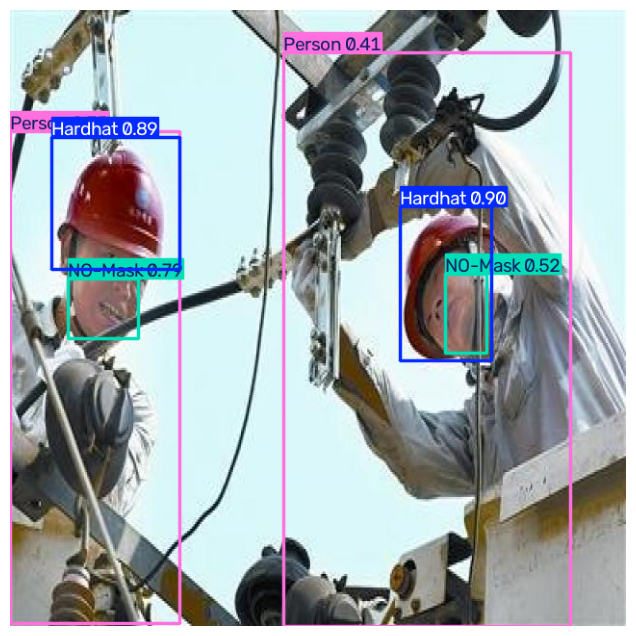

In [31]:
import matplotlib.pyplot as plt
import cv2

sample_path = os.path.join(test_img_dir, sample_images[1])
results = model(sample_path, conf=CONFIDENCE_THRESHOLD)
annotated = results[0].plot()  # returns numpy array with boxes drawn
plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()